# Purpose :
the purpose of this notebook is to analyse all the features of the data provided. House price prediction dataset is known for it's variety in features and it's complex meta-features. 

it's quite difficult to get a perfect accuracy, because it depends on all the pieces working for positivie evaluation. 

all the feature engineering techniques are gonna be applied for this dataset to practice my learning as well as think from ML engineer perspective

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df_train = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv')
df_train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

> the following description is directly copied from claude AI, so make sure you read carefully. Click to view
# 🏠 House Prices: Advanced Regression Techniques
### Kaggle Dataset — Complete Feature Engineering Reference

**URL:** https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques

---

## Overview

| Property | Value |
|---|---|
| Source | Ames Housing Dataset — Dean De Cock (2011) |
| Domain | Real Estate / Residential Housing |
| Location | Ames, Iowa, USA (2006–2010) |
| Task | Supervised Regression |
| Target Variable | `SalePrice` — final sale price of the house in USD |
| Training Rows | 1,460 |
| Test Rows | 1,459 |
| Total Features | 79 (excluding `Id`) |
| Missing Value Columns | 19 columns have at least one NaN |
| Post-OHE Feature Count | ~331 (after one-hot encoding all categoricals) |

---

## Feature Type Breakdown

| Feature Type | Count | Description |
|---|---|---|
| Numerical — Continuous | 20 | Measured values with infinite possible values in a range |
| Numerical — Discrete | 17 | Countable integers (rooms, cars, year, etc.) |
| Categorical — Ordinal | 23 | Categories with a meaningful, rankable order |
| Categorical — Nominal | 14 | Categories with no natural order |
| Mixed Variables | 4 | Encodes both a category (None/NA) and a numeric measurement |
| Date / Time Variables | 4 | Year and month fields (YearBuilt, YrSold, etc.) |
| **Target Variable** | 1 | `SalePrice` — continuous, right-skewed |

> **Total = 79 features + 1 target (SalePrice)**

---

## 1. Numerical — Continuous Features (20)

These are real-valued measurements. They can take any value within a range, not just integers. Most of these are right-skewed and benefit from log or power transformations (Video 30, 31).

| Feature | Description |
|---|---|
| `LotFrontage` | Linear feet of street connected to the property |
| `LotArea` | Lot size in square feet |
| `MasVnrArea` | Masonry veneer area in sq ft (also a mixed variable) |
| `BsmtFinSF1` | Type 1 finished basement area in sq ft |
| `BsmtFinSF2` | Type 2 finished basement area in sq ft |
| `BsmtUnfSF` | Unfinished basement area in sq ft |
| `TotalBsmtSF` | Total basement area in sq ft |
| `1stFlrSF` | First floor area in sq ft |
| `2ndFlrSF` | Second floor area in sq ft |
| `LowQualFinSF` | Low quality finished area (all floors) in sq ft |
| `GrLivArea` | Above-grade (ground) living area in sq ft |
| `GarageArea` | Garage size in sq ft |
| `WoodDeckSF` | Wood deck area in sq ft |
| `OpenPorchSF` | Open porch area in sq ft |
| `EnclosedPorch` | Enclosed porch area in sq ft |
| `3SsnPorch` | Three-season porch area in sq ft |
| `ScreenPorch` | Screen porch area in sq ft |
| `PoolArea` | Pool area in sq ft |
| `MiscVal` | Dollar value of miscellaneous feature |
| `SalePrice` *(target)* | Sale price in USD |

**Key Notes:**
- `GrLivArea`, `LotArea`, `TotalBsmtSF` are heavily right-skewed → apply `log1p` transform (Video 30)
- `LotFrontage` has ~18% missing values → imputation needed
- Many area features are zero-inflated (no pool, no porch) → consider mixed-variable treatment (Video 33)

---

## 2. Numerical — Discrete Features (17)

These are integer-valued counts. They represent quantities you can count. Do not treat these as continuous for models that care about scale.

| Feature | Description |
|---|---|
| `MSSubClass` | Building class (20 = 1-story 1946+, 60 = 2-story 1946+, etc.) |
| `OverallQual` | Overall material and finish quality (1–10) |
| `OverallCond` | Overall condition rating (1–10) |
| `YearBuilt` | Original construction year |
| `YearRemodAdd` | Year of remodel (same as YearBuilt if no remodel) |
| `BsmtFullBath` | Basement full bathrooms |
| `BsmtHalfBath` | Basement half bathrooms |
| `FullBath` | Full bathrooms above grade |
| `HalfBath` | Half bathrooms above grade |
| `BedroomAbvGr` | Bedrooms above ground |
| `KitchenAbvGr` | Kitchens above ground |
| `TotRmsAbvGrd` | Total rooms above grade (excludes bathrooms) |
| `Fireplaces` | Number of fireplaces |
| `GarageYrBlt` | Year garage was built |
| `GarageCars` | Garage capacity in car count |
| `MoSold` | Month sold (1–12) |
| `YrSold` | Year sold (2006–2010) |

**Key Notes:**
- `MSSubClass` looks numeric but is actually a nominal categorical — do NOT scale it
- `OverallQual` and `OverallCond` can be treated as ordinal (1–10 scale)
- `YearBuilt`, `YearRemodAdd`, `GarageYrBlt`, `YrSold`, `MoSold` are date-type features to engineer (Video 34)
- `MoSold` should be cyclically encoded using `sin(2π * month / 12)` and `cos(2π * month / 12)` to preserve circular structure

---

## 3. Categorical — Ordinal Features (23)

Ordinal variables have a natural, rankable order (e.g., Poor < Fair < Good < Excellent). Use `OrdinalEncoder` with a custom category order, **not** `LabelEncoder` (which assigns order arbitrarily). Relevant to Video 26.

| Feature | Categories (Low → High) |
|---|---|
| `ExterQual` | Po < Fa < TA < Gd < Ex |
| `ExterCond` | Po < Fa < TA < Gd < Ex |
| `BsmtQual` | NA < Po < Fa < TA < Gd < Ex |
| `BsmtCond` | NA < Po < Fa < TA < Gd < Ex |
| `BsmtExposure` | NA < No < Mn < Av < Gd |
| `BsmtFinType1` | NA < Unf < LwQ < Rec < BLQ < ALQ < GLQ |
| `BsmtFinType2` | NA < Unf < LwQ < Rec < BLQ < ALQ < GLQ |
| `HeatingQC` | Po < Fa < TA < Gd < Ex |
| `KitchenQual` | Po < Fa < TA < Gd < Ex |
| `FireplaceQu` | NA < Po < Fa < TA < Gd < Ex |
| `GarageFinish` | NA < Unf < RFn < Fin |
| `GarageQual` | NA < Po < Fa < TA < Gd < Ex |
| `GarageCond` | NA < Po < Fa < TA < Gd < Ex |
| `PoolQC` | NA < Fa < TA < Gd < Ex |
| `Fence` | NA < MnWw < GdWo < MnPrv < GdPrv |
| `LotShape` | IR3 < IR2 < IR1 < Reg |
| `LandSlope` | Sev < Mod < Gtl |
| `Utilities` | ELO < NoSeWa < NoSewr < AllPub |
| `Functional` | Sal < Sev < Maj2 < Maj1 < Mod < Min2 < Min1 < Typ |
| `PavedDrive` | N < P < Y |
| `CentralAir` | N < Y |
| `Electrical` | Mix < FuseP < FuseF < FuseA < SBrkr |
| `LandContour` | Low < HLS < Bnk < Lvl |

**Key Notes:**
- `NA` in most quality columns means "Not Applicable" (no basement, no garage) — **not a missing value**
- Must define `categories` parameter explicitly in `OrdinalEncoder` to preserve rank
- These can also be binned (Video 32) into broader groups: Poor / Average / Good / Excellent

---

## 4. Categorical — Nominal Features (14)

Nominal variables have no meaningful order. Applying integer encoding would introduce false ordinal relationships. Use **One Hot Encoding** (Video 27) or **ColumnTransformer** (Video 28) for these.

| Feature | Unique Values | Description |
|---|---|---|
| `MSZoning` | 5 | General zoning class (RL, RM, C, FV, RH) |
| `Street` | 2 | Road access type (Grvl, Pave) |
| `Alley` | 2 + NA | Alley access type (Grvl, Pave, None) |
| `LotConfig` | 5 | Lot configuration (Inside, Corner, CulDSac, FR2, FR3) |
| `Neighborhood` | 25 | Physical location within Ames city |
| `Condition1` | 9 | Proximity to road/railroad |
| `Condition2` | 8 | Proximity to road/railroad (if second present) |
| `BldgType` | 5 | Type of dwelling (1Fam, 2FmCon, Duplx, TwnhsE, TwnhsI) |
| `HouseStyle` | 8 | Style of dwelling (1Story, 2Story, Split, etc.) |
| `RoofStyle` | 6 | Roof type (Flat, Gable, Hip, etc.) |
| `RoofMatl` | 8 | Roof material |
| `Exterior1st` | 15 | Exterior covering material |
| `Exterior2nd` | 16 | Exterior covering if more than one material |
| `MasVnrType` | 4 | Masonry veneer type (None, BrkCmn, BrkFace, Stone) |
| `Foundation` | 6 | Foundation type (BrkTil, CBlock, PConc, Slab, Stone, Wood) |
| `Heating` | 6 | Heating type |
| `GarageType` | 6 | Garage location (Attchd, Detchd, BuiltIn, etc.) |
| `MiscFeature` | 4 + NA | Misc feature not in other categories (Shed, Tennis Court) |
| `SaleType` | 9 | Type of sale (WD, New, COD, etc.) |
| `SaleCondition` | 6 | Condition of sale (Normal, Abnorml, Partial, etc.) |

**Key Notes:**
- `Neighborhood` with 25 unique values will produce 24 dummy columns after OHE — watch for high dimensionality
- `Condition1`/`Condition2` are related → could be engineered into a single feature
- High-cardinality nominal features like `Neighborhood` can be target-encoded as an alternative to OHE

---

## 5. Mixed Variables (4)

A **mixed variable** encodes two types of information simultaneously: a categorical state (usually "None" or "does not exist") and a numerical measurement when the thing does exist. These require special handling (Video 33).

| Feature | Categorical Part | Numerical Part |
|---|---|---|
| `MasVnrArea` | 0 = no masonry veneer | Actual area in sq ft when present |
| `GarageYrBlt` | NaN = no garage | Year built when garage exists |
| `LotFrontage` | NaN = no street connection | Length in linear feet when connected |
| `PoolArea` | 0 = no pool | Pool area in sq ft when present |

**Correct Handling:**
1. Create a binary flag: `has_masonry = (MasVnrArea > 0).astype(int)`
2. Keep the original column for when the feature is present
3. Zero/NaN here is **semantic** (means "absent"), not a data quality issue

---

## 6. Date and Time Variables (4)

These store temporal information as integers. Raw year/month values are not directly useful — you need to engineer them into meaningful features (Video 34).

| Feature | Type | Engineering Ideas |
|---|---|---|
| `YearBuilt` | Year (discrete) | `age_at_sale = YrSold - YearBuilt` |
| `YearRemodAdd` | Year (discrete) | `years_since_remodel = YrSold - YearRemodAdd`, `was_remodeled = (YearRemodAdd != YearBuilt)` |
| `GarageYrBlt` | Year (discrete) | `garage_age = YrSold - GarageYrBlt` |
| `MoSold` | Month 1–12 | `sin_month = sin(2π * MoSold / 12)`, `cos_month = cos(2π * MoSold / 12)` |
| `YrSold` | Year (discrete) | Can be used as-is or as a market condition indicator |

**Key Concepts:**
- **Cyclical encoding** (sin/cos for `MoSold`): Because month 12 and month 1 are adjacent in reality, a raw integer would incorrectly place them far apart. Sin/cos transforms preserve this circular distance.
- **Age features** are often more predictive than raw years since a model doesn't inherently understand "2000 means older than 2010."

---

## 7. Missing Values Summary

Columns with significant missing data — crucial for your imputation strategy.

| Column | Missing Count | Missing % | Interpretation |
|---|---|---|---|
| `PoolQC` | 1,453 | 99.5% | Most houses have no pool — NA = None |
| `MiscFeature` | 1,406 | 96.3% | Most houses have no misc feature |
| `Alley` | 1,369 | 93.8% | Most have no alley access |
| `Fence` | 1,179 | 80.8% | Most have no fence |
| `FireplaceQu` | 690 | 47.3% | Houses without fireplaces |
| `LotFrontage` | 259 | 17.7% | Genuinely missing — impute with median by Neighborhood |
| `GarageYrBlt` | 81 | 5.5% | No garage |
| `MasVnrArea` | 8 | 0.5% | No masonry |
| `Electrical` | 1 | 0.07% | Single missing value — impute with mode |

---

## 8. Target Variable: SalePrice

| Property | Value |
|---|---|
| Type | Continuous numerical |
| Range | $34,900 – $755,000 |
| Mean | ~$180,921 |
| Median | ~$163,000 |
| Distribution | Right-skewed (positive skew) |
| Recommended Transform | `np.log1p(SalePrice)` before modeling |
| Evaluation Metric | RMSLE (Root Mean Squared Log Error) on Kaggle |

**Why log-transform the target?** The raw `SalePrice` violates the normality assumption required by linear regression. After log-transform, the residuals become normally distributed. RMSLE also penalizes under-prediction more heavily than over-prediction — log-transforming the target aligns your optimization directly with the metric.

---

## 9. Feature Engineering Opportunities Mapped to Your Curriculum

| Your Video | Technique | Features to Apply It On |
|---|---|---|
| V24 — Standardization | Z-score / StandardScaler | `GrLivArea`, `LotArea`, `TotalBsmtSF` |
| V25 — Normalization | MinMaxScaler, RobustScaler | `OverallQual`, `LotFrontage` (use Robust due to outliers) |
| V26 — Ordinal/Label Encoding | OrdinalEncoder with custom order | `ExterQual`, `KitchenQual`, `BsmtQual`, all quality cols |
| V27 — One Hot Encoding | pd.get_dummies / OneHotEncoder | `Neighborhood`, `MSZoning`, `SaleType`, `GarageType` |
| V28 — ColumnTransformer | Different transformers per column group | Combine all the above into a single unified step |
| V29 — ML Pipeline | Pipeline(steps=[...]) | Chain CT → Imputer → Model end-to-end |
| V30 — Function Transformer | log1p, sqrt, reciprocal | `SalePrice` (target), `GrLivArea`, `LotArea` |
| V31 — Power Transformer | Yeo-Johnson (handles zeros) | `LotArea`, `BsmtFinSF1`, any skewed continuous |
| V32 — Binning | KBinsDiscretizer, Quantile | `YearBuilt` → era bins, `OverallQual` → Low/Mid/High |
| V33 — Mixed Variables | Binary flag + raw value | `MasVnrArea`, `PoolArea`, `LotFrontage` |
| V34 — Date/Time | Age features, cyclical encoding | `YearBuilt`, `YearRemodAdd`, `MoSold`, `GarageYrBlt` |

---

## 10. Recommended Column Groups for ColumnTransformer

```python
# Continuous features — apply StandardScaler or PowerTransformer
continuous_cols = [
    'LotFrontage', 'LotArea', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
    'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'GrLivArea',
    'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', 'PoolArea'
]

# Discrete numerical — apply MinMaxScaler or leave as-is for tree models
discrete_cols = [
    'OverallQual', 'OverallCond', 'BsmtFullBath', 'BsmtHalfBath',
    'FullBath', 'HalfBath', 'BedroomAbvGr', 'TotRmsAbvGrd',
    'Fireplaces', 'GarageCars'
]

# Ordinal categorical — apply OrdinalEncoder with custom category order
ordinal_cols = [
    'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC',
    'KitchenQual', 'FireplaceQu', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Functional',
    'LotShape', 'LandSlope', 'PavedDrive', 'Fence', 'PoolQC'
]

# Nominal categorical — apply OneHotEncoder
nominal_cols = [
    'MSZoning', 'Street', 'Alley', 'Neighborhood', 'Condition1',
    'BldgType', 'HouseStyle', 'RoofStyle', 'Foundation',
    'Heating', 'GarageType', 'SaleType', 'SaleCondition',
    'Exterior1st', 'MasVnrType'
]
```

---

*Dataset compiled by Dean De Cock (2011). Published on Kaggle as "House Prices: Advanced Regression Techniques." An expanded, modernized alternative to the classic Boston Housing Dataset.*

In [4]:
# Continuous features — apply StandardScaler or PowerTransformer
cont_cols = [
    'LotFrontage', 'LotArea', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
    'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'GrLivArea',
    'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', 'PoolArea'
]

# Discrete numerical — apply MinMaxScaler or leave as-is for tree models
disc_cols = [
    'OverallQual', 'OverallCond', 'BsmtFullBath', 'BsmtHalfBath',
    'FullBath', 'HalfBath', 'BedroomAbvGr', 'TotRmsAbvGrd',
    'Fireplaces', 'GarageCars'
]

# Ordinal categorical — apply OrdinalEncoder with custom category order
ord_cols = [
    'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC',
    'KitchenQual', 'FireplaceQu', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Functional',
    'LotShape', 'LandSlope', 'PavedDrive', 'Fence', 'PoolQC'
]

# Nominal categorical — apply OneHotEncoder
nom_cols = [
    'MSZoning', 'Street', 'Alley', 'Neighborhood', 'Condition1',
    'BldgType', 'HouseStyle', 'RoofStyle', 'Foundation',
    'Heating', 'GarageType', 'SaleType', 'SaleCondition',
    'Exterior1st', 'MasVnrType'
]

In [5]:
# df_train[cont_cols]
# df_train[disc_cols]
# and so on

# Prominent Features
out of all these, the only most effective features are :-
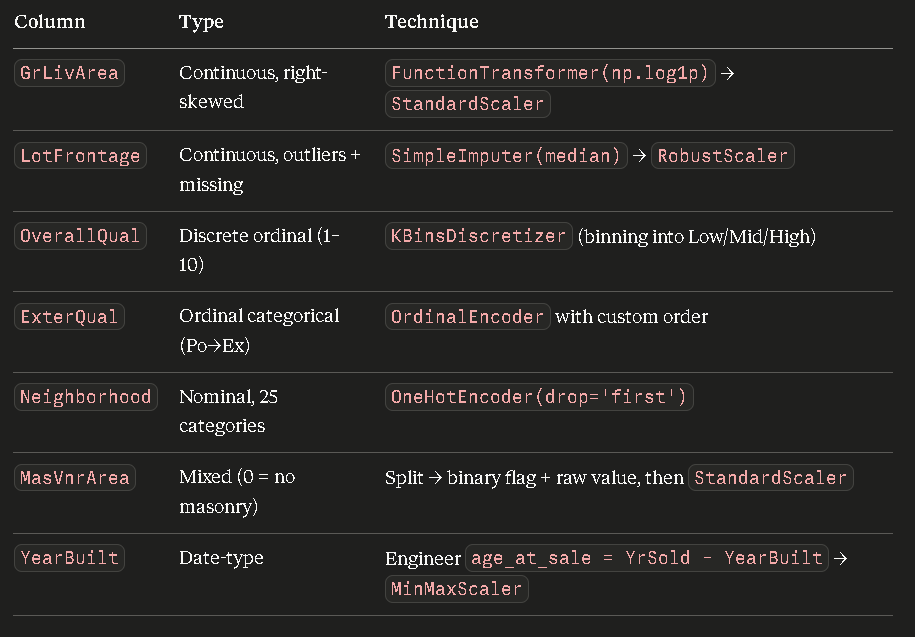

In [6]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler,OneHotEncoder, OrdinalEncoder, RobustScaler
from sklearn.preprocessing import KBinsDiscretizer

from sklearn.impute import SimpleImputer

# 1. GrLivArea
here we'll first do transformation to get a normal distribution and then Standardiaztion
